# Standing Wave Calculator Experiment

This notebook demonstrates and visualizes the `_standing_wave_calculator` function from `animgen.animation.wave` which evaluates standing waves along an armature's spine. 

The formula implemented is:
$$u(s, t) = 2 A e^{g s} \cos(k s + \phi_s) \sin(\omega t + \phi_t)$$

Where:
- $A$ is the base amplitude (`wave_amplitude`)
- $g$ is the spatial growth factor (`growth_factor`)
- $k$ is the spatial wave number ($k = 2 \pi N / L$)
- $\omega$ is the temporal angular frequency ($\omega = 2 \pi / T$)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure workspace root is in path to import animgen
sys.path.append(os.path.abspath('..'))

from animgen.animation.wave import _standing_wave_calculator

## 1. Static Wave Visualization
We plot the wave displacement along the armature for a selection of static timestamps across one cycle period.

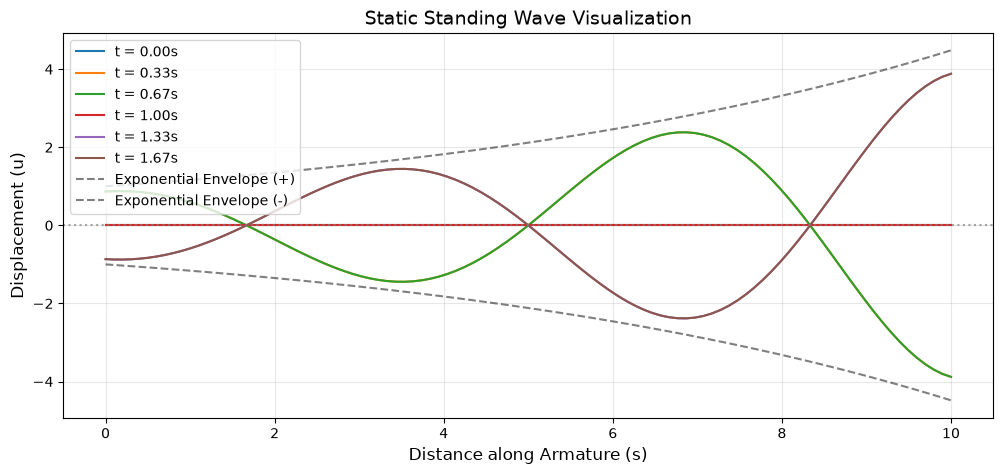

In [2]:
total_length = 10.0
distances = np.linspace(0, total_length, 100)
wave_amplitude = 0.5
wave_duration = 2.0  # 2 seconds cycle duration
growth_factor = 0.15 # grows exponentially along the armature
num_waves = 1.5      # 1.5 full waves over the armature length

# Evaluate at 6 different timestamps in one cycle
time_stamps = np.linspace(0, wave_duration, 6, endpoint=False)

wave_displacements = _standing_wave_calculator(
    distances=distances,
    wave_amplitude=wave_amplitude,
    wave_duration=wave_duration,
    time_stamps=time_stamps,
    growth_factor=growth_factor,
    num_waves=num_waves
)

plt.figure(figsize=(12, 5))
for i, t in enumerate(time_stamps):
    plt.plot(distances, wave_displacements[i], label=f"t = {t:.2f}s")

# Plot envelopes (exponential growth boundary)
envelope = 2 * wave_amplitude * np.exp(growth_factor * distances)
plt.plot(distances, envelope, 'k--', alpha=0.5, label="Exponential Envelope (+)")
plt.plot(distances, -envelope, 'k--', alpha=0.5, label="Exponential Envelope (-)")

plt.title("Static Standing Wave Visualization", fontsize=14)
plt.xlabel("Distance along Armature (s)", fontsize=12)
plt.ylabel("Displacement (u)", fontsize=12)
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.show()

## 2. Interactive Standing Wave Explorer (Flicker-Free & Animated)
This interactive tool automatically animates the wave over time at a fixed 2-second duration. You can adjust the **Wave Speed** slider to speed up or slow down the oscillation, and modify spatial growth, amplitude, wave count, and phases in real-time.

In [ ]:
from ipywidgets import FloatSlider, IntSlider, Play, jslink, HBox, VBox
import ipywidgets as widgets
from IPython.display import display

# Close previous plots to free memory and prevent double rendering
plt.close('all')

# Set up the Play widget for loop animation (frames 0 to 99)
play = Play(
    value=0,
    min=0,
    max=99,
    step=1,
    interval=40,  # ~25 FPS for smooth updates
    description="Play",
    loop=True
)

frame_slider = IntSlider(value=0, min=0, max=99, description='Frame')
jslink((play, 'value'), (frame_slider, 'value'))

# Configurable parameter sliders
amplitude_slider = FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1, description='Amplitude')
growth_slider = FloatSlider(value=0.15, min=-0.5, max=0.5, step=0.05, description='Growth Rate')
waves_slider = FloatSlider(value=1.5, min=0.5, max=5.0, step=0.1, description='Num Waves')
speed_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Wave Speed')
phi_s_slider = FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.1, description='Phase Spatial')
phi_t_slider = FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.1, description='Phase Temporal')

def plot_interactive(frame, wave_amplitude, growth_factor, num_waves, wave_speed, phi_s, phi_t):
    # Close any background open figures to save memory
    plt.close('all')
    
    distances = np.linspace(0, 10.0, 100)
    wave_duration = 2.0  # Fixed 2-second base duration
    
    # Calculate current time step in seconds based on frame
    base_time = (frame / 100.0) * wave_duration
    # Scale elapsed time dynamically by wave_speed
    effective_time = base_time * wave_speed
    
    # Calculate displacements
    wave_displacement = _standing_wave_calculator(
        distances=distances,
        wave_amplitude=wave_amplitude,
        wave_duration=wave_duration,
        time_stamps=effective_time,
        growth_factor=growth_factor,
        num_waves=num_waves,
        phi_s=phi_s,
        phi_t=phi_t
    )
    
    plt.figure(figsize=(12, 6))
    
    # Draw the dynamic envelope bounds
    envelope = 2 * wave_amplitude * np.exp(growth_factor * distances)
    plt.plot(distances, envelope, 'k--', alpha=0.3, label="Exponential Envelope (+)")
    plt.plot(distances, -envelope, 'k--', alpha=0.3, label="Exponential Envelope (-)")
    
    # Draw current displacement
    plt.plot(distances, wave_displacement[0], 'r-', linewidth=2.5, label=f"Wave state (effective time = {effective_time:.2f}s)")
    
    # Calculate y-limits dynamically so it fits perfectly but remains stable
    max_env = 2 * wave_amplitude * np.exp(max(0, growth_factor) * 10.0)
    plt.ylim(-max_env * 1.15, max_env * 1.15)
    
    plt.title("Flicker-Free Animated Standing Wave Simulator", fontsize=14)
    plt.xlabel("Distance along Armature (s)", fontsize=12)
    plt.ylabel("Displacement (u)", fontsize=12)
    plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
    plt.grid(True, alpha=0.2)
    plt.legend(loc="upper left")
    plt.show()

# Connect widgets using interactive_output to buffer output and prevent flickering
out = widgets.interactive_output(
    plot_interactive,
    {
        'frame': frame_slider,
        'wave_amplitude': amplitude_slider,
        'growth_factor': growth_slider,
        'num_waves': waves_slider,
        'wave_speed': speed_slider,
        'phi_s': phi_s_slider,
        'phi_t': phi_t_slider
    }
)

# Layout controls in a nice vertical stack of horizontal rows
controls = VBox([
    HBox([play, frame_slider]),
    HBox([amplitude_slider, growth_slider]),
    HBox([waves_slider, speed_slider]),
    HBox([phi_s_slider, phi_t_slider])
])

display(controls, out)

Output()